# Crypto: Cross-Sectional Signals on the Top 30 Pairs

The same signal-and-portfolio framework as the equity notebooks, applied
to daily Binance.US data on the 30 most liquid USDT spot pairs. The
universe spans 2019-09 (Binance.US launch) to present; many alts begin
later than that and are absent until their listing date.

What changes versus equities:

- **No index membership.** The universe is the curated list of liquid
  pairs; we drop names per date when they have no data yet, but there
  is no analogue to the S&P 500 add/remove process.
- **Calendar.** Crypto trades 24/7. Annualisation uses 365 instead of
  252 trading days.
- **Execution.** `exec_lag=1` is realistic; a daily-close signal can be
  acted on the next close with seconds of latency, not the next session.
- **Costs.** 10 bps per side reflects Binance.US taker fees; institutional
  spot can be tighter. Dollar-neutral construction implies trading the
  short side via perpetual futures, where funding cost can be substantial
  during regime turns and is not modelled here.
- **Universe size.** 30 names vs ~500 equities. Cross-sectional breadth
  is much smaller, so the realistic Sharpe ceiling is lower per the
  fundamental law of active management.

**Significance verdict (10 bps cost, HAC SE, with combiner look-ahead bug fixed):** Standalone optimised volume-adjusted momentum reaches Sharpe 0.83, alpha 50.4% annual, **HAC t-stat 2.13 (passes |t| > 2)**. Standalone optimised cross-sectional momentum reaches HAC t = 1.56 (borderline). The IC-weighted combined portfolio reports Sharpe 0.19 in-sample (t = 0.30) and Sharpe -0.50 out-of-sample (t = -0.71) once the combiner's IC weighting is shifted by the full horizon. An earlier version of this notebook reported the combined at HAC t = 2.55 -- that was a look-ahead artefact (combiner shifted IC by 1 day instead of `horizon`). Only the standalone VolMom result survives the audit.



**Fifth signal: volume-adjusted momentum (`VolMom`).** Mean rolling return scaled by the square root of relative volume (`mean_return * sqrt(volume / rolling_mean_volume)`). Ported in from an earlier crypto-momentum study and run through the same IC-weighted combiner.


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from signals import mean_reversion, momentum, low_volatility, market_residual_momentum, volume_adjusted_momentum
from helper import (
    Optimizer, port_ret, quick_weights, stats, ic, ic_weighted_combine,
    dist_plot, var_cvar, probabilistic_sharpe, deflated_sharpe,
)

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

PPY = 365  # crypto annualisation

## Data

In [2]:
raw = pd.read_parquet('../data/crypto.parquet')
close = raw['Close']
returns = close.pct_change()
btc = close['BTC']
btc_ret = btc.pct_change()

print(f"Universe: {close.shape[1]} pairs, {len(close)} daily bars")
print(f"Date range: {close.index.min().date()} to {close.index.max().date()}")
print(f"Names with full history from start: {close.iloc[0].notna().sum()}")

Universe: 30 pairs, 2383 daily bars
Date range: 2019-09-23 to 2026-04-01
Names with full history from start: 6


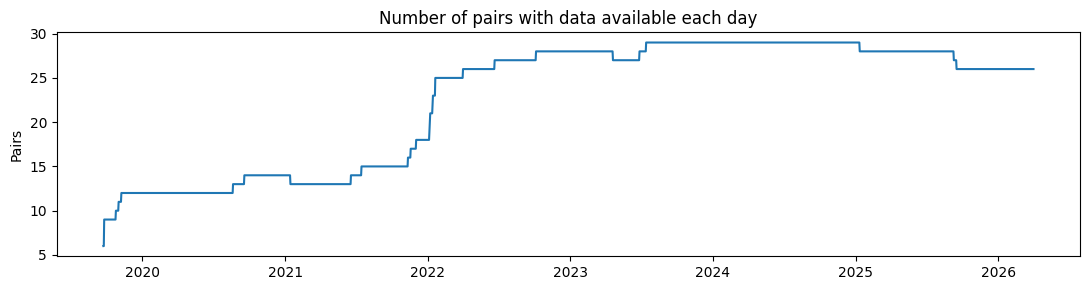

In [3]:
coverage = close.notna().sum(axis=1)
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(coverage)
ax.set_title('Number of pairs with data available each day')
ax.set_ylabel('Pairs')
plt.tight_layout()
plt.show()

## Signals

In [4]:
# Same lookbacks as the equity notebooks, applied to the crypto panel.
sig_mr = mean_reversion(close, lookback=20)
sig_mom = momentum(close, lookback=252, skip=21)
sig_lv = low_volatility(close, lookback=63)
sig_resmom = market_residual_momentum(close, btc, lookback=252, skip=21, beta_lookback=252)
sig_volmom = volume_adjusted_momentum(close, raw['Volume'], lookback=20)

signals = {
    'MeanRev': sig_mr,
    'Momentum': sig_mom,
    'LowVol': sig_lv,
    'ResMom': sig_resmom,
    'VolMom': sig_volmom,
}
{name: s.notna().sum().sum() for name, s in signals.items()}

{'MeanRev': np.int64(53285),
 'Momentum': np.int64(46167),
 'LowVol': np.int64(51921),
 'ResMom': np.int64(38487),
 'VolMom': np.int64(53254)}

## Information Coefficient

In [5]:
ic_table = {}
for name, sig in signals.items():
    ic_table[name] = ic(sig, close, horizons=(1, 3, 7, 14))
ic_df = pd.concat(ic_table, axis=1)
ic_df

MeanRev         Momentum        LowVol         ResMom          VolMom  \
        IC    ICIR       IC   ICIR     IC   ICIR      IC    ICIR      IC   
1   0.0507  0.1805   0.0093 0.0308 0.0609 0.1860 -0.0040 -0.0136 -0.0284   
3   0.0280  0.1008   0.0226 0.0734 0.0760 0.2289  0.0035  0.0117 -0.0155   
7   0.0048  0.0175   0.0350 0.1110 0.0973 0.2971  0.0080  0.0255 -0.0097   
14 -0.0027 -0.0095   0.0492 0.1518 0.1156 0.3456  0.0170  0.0522 -0.0055   

            
      ICIR  
1  -0.0979  
3  -0.0528  
7  -0.0341  
14 -0.0187

IC numbers near zero are expected. With ~30 names per date the
cross-sectional Spearman correlation has substantial sampling noise; the
ICIR column is the more reliable comparison across signals.

## Rank-Weighted Backtest

In [6]:
# Long-only rank-weighted version: every pair gets a weight proportional
# to its cross-sectional rank in the signal. No optimization, no shorts.
rows = []
for name, sig in signals.items():
    w = quick_weights(sig, dollar_neutral=False, long_only=True,
                      fully_invested=True)
    pnl = port_ret(w, returns, tcost_bps=10, exec_lag=1)
    s = stats(pnl.dropna(), weights=w, benchmark=btc_ret, plot=False,
              periods_per_year=PPY)
    rows.append(s.rename(index={'Strategy': name}))
pd.concat(rows)

,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta,daily_turnover
MeanRev,57.39%,84.10%,0.6820,1.7360,-89.60%,-57.75%,1788 days,0.48%,0.0250,1.0980,24.64%
Momentum,63.47%,80.98%,0.7840,1.8930,-81.26%,-49.59%,1604 days,8.47%,0.4050,1.1140,4.05%
LowVol,60.46%,76.29%,0.7930,1.9980,-82.28%,-49.44%,1786 days,2.92%,0.1740,1.0510,2.71%
ResMom,33.07%,78.27%,0.4220,0.9590,-83.38%,-58.94%,1788 days,2.09%,0.1000,1.1310,3.60%
VolMom,61.20%,82.85%,0.7390,1.8790,-89.40%,-57.10%,1789 days,5.05%,0.2420,1.0820,23.33%


In [7]:
# Dollar-neutral version: long winners, short losers. Assumes access to
# perp futures or shorting facility. Funding cost is not modelled.
rows = []
for name, sig in signals.items():
    w = quick_weights(sig, dollar_neutral=True, fully_invested=True)
    pnl = port_ret(w, returns, tcost_bps=10, exec_lag=1)
    s = stats(pnl.dropna(), weights=w, benchmark=btc_ret, plot=False,
              periods_per_year=PPY)
    rows.append(s.rename(index={'Strategy': name}))
pd.concat(rows)

,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta,daily_turnover
MeanRev,-15.36%,31.22%,-0.4920,-1.2520,-91.94%,-76.12%,2350 days,-15.98%,-1.3520,0.0120,51.78%
Momentum,0.92%,24.97%,0.0370,0.0890,-31.02%,-15.57%,1666 days,1.08%,0.1070,-0.0030,8.50%
LowVol,-14.84%,34.08%,-0.4350,-1.0970,-81.89%,-65.18%,2211 days,-9.20%,-0.7170,-0.1030,5.67%
ResMom,-3.37%,22.43%,-0.1500,-0.3410,-42.68%,-26.32%,1808 days,-3.39%,-0.3340,0.0010,7.59%
VolMom,-5.24%,32.10%,-0.1630,-0.4150,-77.06%,-41.38%,1914 days,-4.05%,-0.3340,-0.0230,48.98%


## Optimized Backtest

In [8]:
# Per-signal mean-variance optimization. 10% per-name cap reflects the
# small universe (~25 names traded per date); 2x gross leverage cap.
opt_results = {}
opt_pnls = {}
for name, sig in signals.items():
    sig_clean = sig.dropna(how='all')
    rets_clean = returns.reindex(sig_clean.index)
    opt = Optimizer(sig_clean, rets_clean)
    w = opt.run(dollar_neutral=True, max_position=0.10, max_leverage=2.0,
                subsample=5, verbose=False)
    pnl = port_ret(w, rets_clean, tcost_bps=10, exec_lag=1)
    opt_pnls[name] = pnl
    s = stats(pnl.dropna(), weights=w, benchmark=btc_ret, plot=False,
              periods_per_year=PPY)
    opt_results[name] = s.rename(index={'Strategy': name})
pd.concat(opt_results.values())

,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta,daily_turnover
MeanRev,-66.19%,59.32%,-1.1160,-2.8390,-99.71%,-91.61%,2329 days,-73.53%,-3.1720,0.1420,32.60%
Momentum,50.10%,56.94%,0.8800,2.1260,-56.19%,-21.65%,1189 days,35.31%,1.5630,0.3000,6.86%
LowVol,-58.17%,71.37%,-0.8150,-2.0540,-99.79%,-91.85%,2211 days,-15.14%,-0.7090,-0.7860,4.82%
ResMom,-4.42%,39.70%,-0.1110,-0.2520,-58.77%,-30.16%,1807 days,-7.66%,-0.4520,0.1180,6.62%
VolMom,48.62%,58.77%,0.8270,2.1040,-58.57%,-29.20%,1786 days,50.42%,2.1300,-0.0350,26.98%


## IC-Weighted Combined Portfolio

In [9]:
combined, ic_weights = ic_weighted_combine(
    signals, close, lookback=90, min_ic=0.0, horizon=14
)
ic_weights.mean().round(3).rename('avg_weight')

MeanRev    0.1360
Momentum   0.1530
LowVol     0.4260
ResMom     0.0930
VolMom     0.1930
Name: avg_weight, dtype: float64

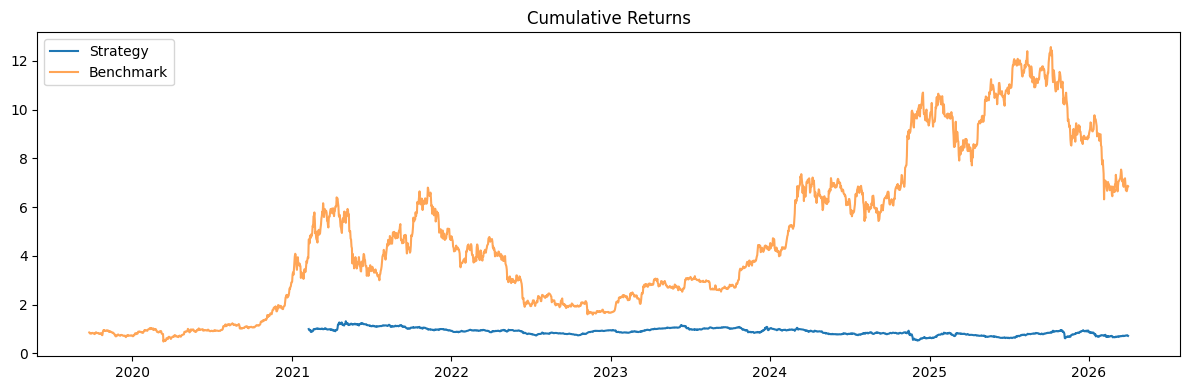

,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta,daily_turnover
Strategy,-0.13%,35.23%,-0.0040,-0.0080,-59.91%,-31.40%,1777 days,0.29%,0.0180,-0.0170,14.95%


In [10]:
# Optimize the combined signal end-to-end.
combined_clean = combined.dropna(how='all')
rets_clean = returns.reindex(combined_clean.index)
opt = Optimizer(combined_clean, rets_clean)
w_combined = opt.run(dollar_neutral=True, max_position=0.10,
                     max_leverage=2.0, subsample=5, verbose=False)
pnl_combined = port_ret(w_combined, rets_clean, tcost_bps=10, exec_lag=1)
stats_combined = stats(pnl_combined.dropna(), weights=w_combined,
                       benchmark=btc_ret, plot=True, periods_per_year=PPY)
stats_combined

In [11]:
# Probabilistic and Deflated Sharpe ratios.
n_trials = 5 * 2  # 5 signals x 2 weighting schemes considered
print(f'PSR (target 0):       {probabilistic_sharpe(pnl_combined.dropna(), periods_per_year=PPY):.3f}')
print(f'DSR (n_trials={n_trials}):     {deflated_sharpe(pnl_combined.dropna(), n_trials=n_trials, periods_per_year=PPY):.3f}')

PSR (target 0):       0.497
DSR (n_trials=10):     0.037


## Out-of-Sample Validation

Split the combined signal at 2024-01-01. The Optimizer is fit separately on each window (IS cov from IS returns only, OOS cov from OOS returns only), so neither window peeks at the other.


In [12]:
CRYPTO_IS_END = '2023-12-31'

is_signal = combined.loc[:CRYPTO_IS_END].dropna(how='all')
is_ret = returns.reindex(is_signal.index)
opt_is = Optimizer(is_signal, is_ret)
w_is = opt_is.run(dollar_neutral=True, max_position=0.10, max_leverage=2.0, subsample=5, verbose=False)
pnl_is = port_ret(w_is, is_ret, tcost_bps=10, exec_lag=1)
stats_is = stats(pnl_is.dropna(), weights=w_is, benchmark=btc_ret.reindex(is_signal.index), plot=False, periods_per_year=PPY)
stats_is.rename(index={'Strategy': 'In-sample (2019-09 to 2023-12)'})

,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta,daily_turnover
In-sample (2019-09 to 2023-12),5.55%,28.65%,0.1940,0.3290,-42.02%,-22.94%,971 days,5.28%,0.3000,0.0120,13.53%


In [13]:
oos_signal = combined.loc[CRYPTO_IS_END:].dropna(how='all')
oos_ret = returns.reindex(oos_signal.index)
opt_oos = Optimizer(oos_signal, oos_ret)
w_oos = opt_oos.run(dollar_neutral=True, max_position=0.10, max_leverage=2.0, subsample=5, verbose=False)
pnl_oos = port_ret(w_oos, oos_ret, tcost_bps=10, exec_lag=1)
stats_oos = stats(pnl_oos.dropna(), weights=w_oos, benchmark=btc_ret.reindex(oos_signal.index), plot=False, periods_per_year=PPY)
stats_oos.rename(index={'Strategy': 'Out-of-sample (2024-01+)'})

,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta,daily_turnover
Out-of-sample (2024-01+),-21.56%,43.04%,-0.5010,-0.7440,-59.32%,-39.24%,802 days,-20.16%,-0.7140,-0.0510,15.76%


In [14]:
print(f'IS  PSR: {probabilistic_sharpe(pnl_is.dropna(), periods_per_year=PPY):.3f}   '
      f'DSR(10): {deflated_sharpe(pnl_is.dropna(), n_trials=10, periods_per_year=PPY):.3f}')
print(f'OOS PSR: {probabilistic_sharpe(pnl_oos.dropna(), periods_per_year=PPY):.3f}   '
      f'DSR(10): {deflated_sharpe(pnl_oos.dropna(), n_trials=10, periods_per_year=PPY):.3f}')

IS  PSR: 0.629   DSR(10): 0.156
OOS PSR: 0.223   DSR(10): 0.025


## Return Distribution and Tail Risk

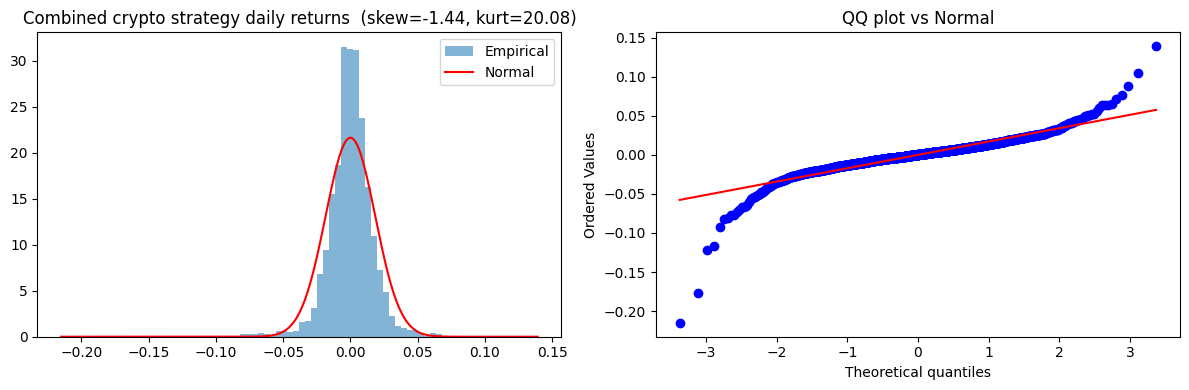

In [15]:
dist_plot(pnl_combined.dropna(), title='Combined crypto strategy daily returns')

In [16]:
var_cvar(pnl_combined.dropna(), alpha=0.05)

,VaR,CVaR
historical,-2.43%,-4.43%
parametric,-3.03%,-3.80%


In [17]:
var_cvar(pnl_combined.dropna(), alpha=0.01)

,VaR,CVaR
historical,-5.42%,-8.79%
parametric,-4.29%,-4.92%


## Rolling Sharpe

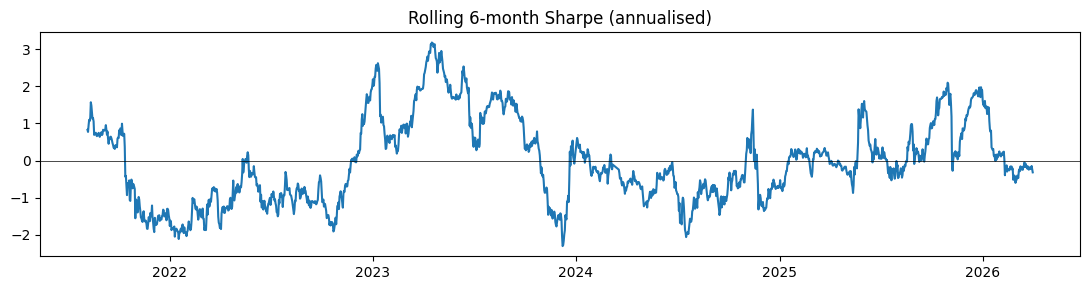

In [18]:
rolling_sharpe = (pnl_combined.rolling(180).mean() /
                  pnl_combined.rolling(180).std()) * np.sqrt(PPY)
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(rolling_sharpe)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_title('Rolling 6-month Sharpe (annualised)')
plt.tight_layout()
plt.show()

## Caveats specific to crypto

- **Short history.** Six years of data, much of it concentrated in 2021
  and 2022, is not enough to distinguish signal from regime. Walk-forward
  validation on this universe has only 2-3 reasonable windows.
- **Funding rates.** Dollar-neutral construction implicitly assumes a
  perpetual-futures short leg. Funding can swing from -50 bps to +100 bps
  per 8 hours during volatile periods and is not in the backtest.
- **Survivorship in the universe.** The 30-pair list is curated by
  today's market-cap rank. Pairs that delisted from Binance.US (a
  handful, e.g. some that the SEC flagged) are absent. This is a
  smaller bias than in equities because crypto exchange delistings are
  rarer than equity delistings, but it exists.
- **Exchange-specific microstructure.** Binance.US prices can diverge
  from Coinbase or Kraken by 5-50 bps; cross-exchange arbitrage is
  out of scope here.